# Round 4 — HYDROGEL_PACK research

**Scope:** hydrogel only. No VEV / no VE / no manual exotics here.
**Guide:** [`round4_research.md`](round4_research.md). Every section maps to a gate or question from there.

## What we want to learn (from `round4_research.md` §0, §2.2, §2.3)

1. **L1 — anchor.** Is `HP_MEAN = 9991` still the right anchor on round-4 data, or has it drifted?
2. **L2 — vol.** Is the round-3 vol-armor (`min(1, 30/std50)`) still calibrated for round 4?
3. **L3/L4 — dev thresholds.** Do `dev > 22` (take) and `dev > 14` (make) still cover the right tails?
4. **New info — counterparties.** `Trade.buyer/seller` are now populated. For hydrogel, who shows up, who's on which side, and is any of them informed (price drifts after they trade) vs passive (price reverts)?
5. **Anti-pattern check.** Anything we find should be a **classification** (informed/passive/noise) feeding a **discrete gate** (skip / shrink / fully take). No regressions, no continuous coefficients on 3 days of data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_rows', 80)
pd.set_option('display.width', 160)

ROOT = Path('..').resolve()
R4 = ROOT / 'dataset' / 'ROUND_4'
R3 = ROOT / 'dataset' / 'ROUND_3'

PRODUCT = 'HYDROGEL_PACK'
POSITION_LIMIT = 200

# Round-3 submitted parameters (the structural baseline we are layering on top of)
HP_MEAN_R3 = 9991
HP_MEAN_R4 = 9995
DEV_TAKE = 22
DEV_MAKE = 14
STD50_VOL_ARMOR = 30   # vol_scale = min(1, 30/std50)

print('paths ok:', R4.exists(), R3.exists())

paths ok: True True


## 1. Load round-4 hydrogel data

Two tables per day:
- **prices** — order-book snapshots (per timestamp, per product).
- **trades** — actual prints. **New in round 4:** `buyer` and `seller` are filled with `Mark NN` IDs (in round 3 these were always blank). The whole point of this notebook is to mine that field for hydrogel.

In [2]:
def _round_label(folder):
    # folder name 'ROUND_3' / 'ROUND_4' -> 'round_3' / 'round_4'
    return folder.name.replace('ROUND', 'round').lower()

def load_prices(folder, days, product):
    label = _round_label(folder)
    frames = []
    for d in days:
        f = folder / f'prices_{label}_day_{d}.csv'
        df = pd.read_csv(f, sep=';')
        df = df[df['product'] == product].copy()
        df['day'] = d
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

def load_trades(folder, days, product):
    label = _round_label(folder)
    frames = []
    for d in days:
        f = folder / f'trades_{label}_day_{d}.csv'
        df = pd.read_csv(f, sep=';')
        df = df[df['symbol'] == product].copy()
        df['day'] = d
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

px4 = load_prices(R4, [1, 2, 3], PRODUCT)
tr4 = load_trades(R4, [1, 2, 3], PRODUCT)
px3 = load_prices(R3, [0, 1, 2], PRODUCT)
tr3 = load_trades(R3, [0, 1, 2], PRODUCT)

print('round 4 prices:', len(px4), 'trades:', len(tr4))
print('round 3 prices:', len(px3), 'trades:', len(tr3))
px4.head(3)

round 4 prices: 30000 trades: 1022
round 3 prices: 30000 trades: 1010


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,1,0,HYDROGEL_PACK,9950,13,9947.0,23.0,NaN,NaN,9966,13,9968.0,23.0,NaN,NaN,9958.0,0.0
1,1,100,HYDROGEL_PACK,9953,15,9950.0,21.0,NaN,NaN,9969,15,9971.0,21.0,NaN,NaN,9961.0,0.0
2,1,200,HYDROGEL_PACK,9953,14,9951.0,21.0,NaN,NaN,9969,14,9972.0,21.0,NaN,NaN,9961.0,0.0


## 2. The new field: counterparty IDs

Confirm that `buyer` / `seller` are populated in round 4 and were absent in round 3. This is the only datamodel change carrying alpha potential.

In [3]:
def cp_coverage(df, label):
    n = len(df)
    nb = df['buyer'].notna().sum()
    ns = df['seller'].notna().sum()
    print(f'{label}: trades={n} buyer_filled={nb} ({nb/n:.0%}) seller_filled={ns/n:.0%}')

cp_coverage(tr3, 'round 3')
cp_coverage(tr4, 'round 4')

print('\nUnique buyers (R4):', sorted(tr4['buyer'].dropna().unique().tolist()))
print('Unique sellers (R4):', sorted(tr4['seller'].dropna().unique().tolist()))

round 3: trades=1010 buyer_filled=0 (0%) seller_filled=0%
round 4: trades=1022 buyer_filled=1022 (100%) seller_filled=100%

Unique buyers (R4): ['Mark 14', 'Mark 22', 'Mark 38']
Unique sellers (R4): ['Mark 14', 'Mark 22', 'Mark 38']


**Expected result:** round 3 = 0% filled, round 4 = 100% filled. Hydrogel has only **3 distinct counterparties** (Mark 14, Mark 22, Mark 38) — small enough that we can label every one of them by hand from the per-CP tape.

In [4]:
# Counterparty pair frequency: who trades with whom
pair = (tr4.assign(pair=tr4['buyer'] + ' -> ' + tr4['seller'])
             .groupby(['day', 'pair']).size().unstack(fill_value=0))
pair.loc['ALL'] = pair.sum(axis=0)
pair

pair,Mark 14 -> Mark 38,Mark 22 -> Mark 38,Mark 38 -> Mark 14,Mark 38 -> Mark 22
day,,,,
1,183,3,187,2
2,142,4,161,4
3,171,4,159,2
ALL,496,11,507,8


## 3. Per-counterparty profile (research.md §2.2 questions 1, 3)

For each counterparty: trade count, side ratio (always-buyer / always-seller / two-sided), trade size distribution, presence pattern across days.

In [5]:
def cp_profile(tr):
    cps = pd.unique(tr[['buyer', 'seller']].values.ravel())
    rows = []
    for cp in cps:
        if pd.isna(cp):
            continue
        as_buy = tr[tr['buyer'] == cp]
        as_sell = tr[tr['seller'] == cp]
        n_buy = len(as_buy)
        n_sell = len(as_sell)
        n_tot = n_buy + n_sell
        rows.append({
            'cp': cp,
            'n_total': n_tot,
            'n_buy': n_buy,
            'n_sell': n_sell,
            'buy_share': n_buy / n_tot,
            'mean_qty_buy': as_buy['quantity'].mean() if n_buy else np.nan,
            'mean_qty_sell': as_sell['quantity'].mean() if n_sell else np.nan,
            'max_qty': tr[(tr['buyer'] == cp) | (tr['seller'] == cp)]['quantity'].max(),
        })
    return pd.DataFrame(rows).sort_values('n_total', ascending=False).reset_index(drop=True)

cp_profile(tr4)

,cp,n_total,n_buy,n_sell,buy_share,mean_qty_buy,mean_qty_sell,max_qty
0,Mark 38,1022,515,507,0.503914,4.009709,4.005917,6
1,Mark 14,1003,496,507,0.494516,4.010081,4.009862,6
2,Mark 22,19,11,8,0.578947,3.818182,4.000000,6


In [6]:
# Per-day presence — does any counterparty appear only on certain days?
for cp in sorted(tr4['buyer'].dropna().unique()):
    rows = []
    for d in [1, 2, 3]:
        sub = tr4[tr4['day'] == d]
        rows.append({
            'day': d,
            'as_buyer': (sub['buyer'] == cp).sum(),
            'as_seller': (sub['seller'] == cp).sum(),
        })
    print(cp)
    print(pd.DataFrame(rows).to_string(index=False))
    print()

Mark 14
 day  as_buyer  as_seller
   1       183        187
   2       142        161
   3       171        159

Mark 22
 day  as_buyer  as_seller
   1         3          2
   2         4          4
   3         4          2

Mark 38
 day  as_buyer  as_seller
   1       189        186
   2       165        146
   3       161        175



## 4. Anchor verification — is `HP_MEAN = 9991` still right? (L1)

If the mid distribution drifted in round 4, the round-3 anchor mean-reverts toward a stale level and the variant bleeds. Compare the round-3 vs round-4 mid distributions side-by-side.

In [7]:
def mid_summary(px, label):
    print(label)
    print(px.groupby('day')['mid_price'].agg(['mean', 'median', 'std', 'min', 'max']).round(2))
    print(f'  pooled mean={px["mid_price"].mean():.2f}  median={px["mid_price"].median():.2f}')
    print()

mid_summary(px3, 'ROUND 3')
mid_summary(px4, 'ROUND 4')

ROUND 3
        mean  median    std     min      max
day                                         
0    9990.96  9991.0  25.33  9928.0  10071.0
1    9992.06  9999.0  37.61  9908.5  10079.0
2    9989.40  9993.0  31.62  9891.0  10051.0
  pooled mean=9990.81  median=9994.00

ROUND 4
         mean    median    std     min      max
day                                            
1     9992.06   9999.00  37.61  9908.5  10079.0
2     9989.40   9993.00  31.62  9891.0  10051.0
3    10002.50  10007.25  32.95  9923.0  10081.0
  pooled mean=9994.65  median=9999.00



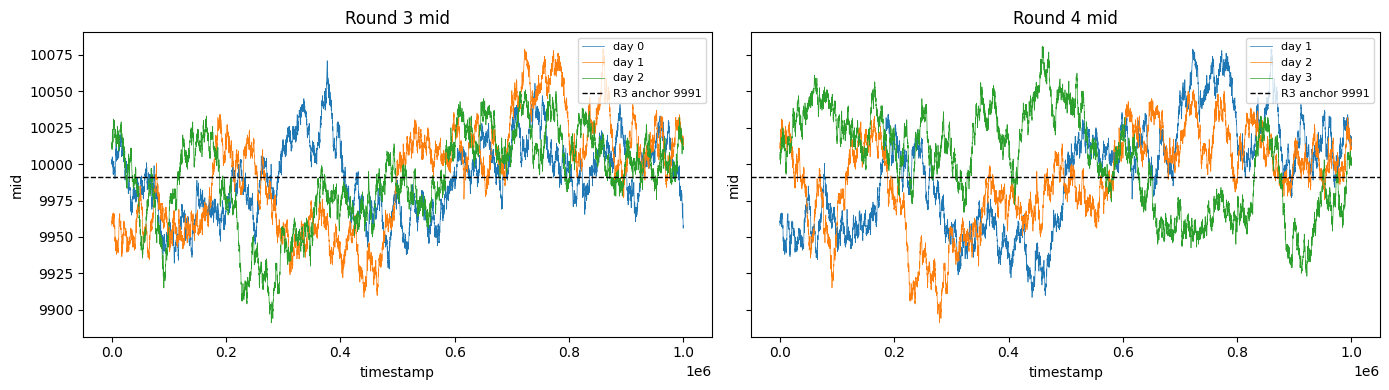

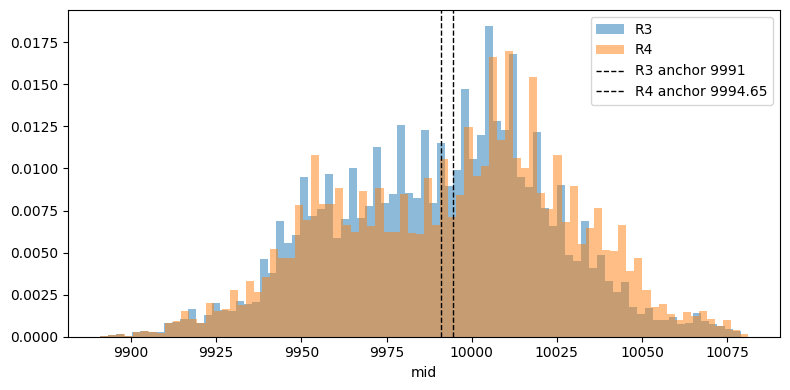

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (px, label) in zip(axes, [(px3, 'Round 3'), (px4, 'Round 4')]):
    for d in sorted(px['day'].unique()):
        sub = px[px['day'] == d]
        ax.plot(sub['timestamp'].values, sub['mid_price'].values, lw=0.5, label=f'day {d}')
    ax.axhline(HP_MEAN_R3, color='k', ls='--', lw=1, label=f'R3 anchor {HP_MEAN_R3}')
    ax.set_title(f'{label} mid'); ax.legend(loc='upper right', fontsize=8)
    ax.set_xlabel('timestamp'); ax.set_ylabel('mid')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(px3['mid_price'], bins=80, alpha=0.5, density=True, label='R3')
ax.hist(px4['mid_price'], bins=80, alpha=0.5, density=True, label='R4')
ax.axvline(HP_MEAN_R3, color='k', ls='--', lw=1, label=f'R3 anchor {HP_MEAN_R3}')
r4_anchor = globals().get('HP_MEAN_R4', px4['mid_price'].mean())
ax.axvline(r4_anchor, color='k', ls='--', lw=1, label=f'R4 anchor {r4_anchor:.2f}')
ax.set_xlabel('mid'); ax.legend(); plt.tight_layout(); plt.show()

In [9]:
# Suggested replacement anchor candidates
candidates = {
    'r3_anchor': HP_MEAN_R3,
    'r4_pooled_mean': px4['mid_price'].mean(),
    'r4_pooled_median': px4['mid_price'].median(),
    'r4_day1_median': px4.loc[px4['day'] == 1, 'mid_price'].median(),
    'r4_day3_median': px4.loc[px4['day'] == 3, 'mid_price'].median(),
}
for k, v in candidates.items():
    abs_dev = (px4['mid_price'] - v).abs().mean()
    print(f'{k:>20} = {v:7.2f}   mean |mid - anchor| over R4 = {abs_dev:.2f}')

           r3_anchor = 9991.00   mean |mid - anchor| over R4 = 29.21
      r4_pooled_mean = 9994.65   mean |mid - anchor| over R4 = 28.77
    r4_pooled_median = 9999.00   mean |mid - anchor| over R4 = 28.56
      r4_day1_median = 9999.00   mean |mid - anchor| over R4 = 28.56
      r4_day3_median = 10007.25   mean |mid - anchor| over R4 = 29.28


## 5. Volatility regime — is the vol-armor still calibrated? (L2)

Round 3 used `vol_scale = min(1, 30 / std50)`, where `std50` is the rolling-50 stdev of mid. Recompute `std50` on round-4 mid to see how often armor activates and what the typical scale-down is.

In [10]:
def add_std50(px):
    out = []
    for d, sub in px.groupby('day'):
        sub = sub.sort_values('timestamp').copy()
        sub['std50'] = sub['mid_price'].rolling(50, min_periods=10).std()
        sub['vol_scale'] = np.minimum(1.0, STD50_VOL_ARMOR / sub['std50'].clip(lower=1e-6))
        out.append(sub)
    return pd.concat(out)

px4v = add_std50(px4)
px3v = add_std50(px3)

print('std50 distribution:')
print(pd.DataFrame({
    'R3': px3v['std50'].describe(),
    'R4': px4v['std50'].describe(),
}).round(2))

print('\nvol_scale = min(1, 30/std50)  — fraction of time armor is active (<1):')
print(f'  R3: {(px3v["vol_scale"] < 1).mean():.1%}   mean when active = {px3v.loc[px3v["vol_scale"] < 1, "vol_scale"].mean():.3f}')
print(f'  R4: {(px4v["vol_scale"] < 1).mean():.1%}   mean when active = {px4v.loc[px4v["vol_scale"] < 1, "vol_scale"].mean():.3f}')

std50 distribution:
             R3        R4
count  29973.00  29973.00
mean       5.08      5.15
std        1.91      1.96
min        1.40      1.61
25%        3.68      3.70
50%        4.70      4.72
75%        6.12      6.25
max       14.06     14.06

vol_scale = min(1, 30/std50)  — fraction of time armor is active (<1):
  R3: 0.0%   mean when active = nan
  R4: 0.0%   mean when active = nan


## Recalculating Deviation distribution thresholds

R4 spread: count    30000.00
mean        15.73
std          1.45
min          7.00
25%         16.00
50%         16.00
75%         16.00
max         17.00
Name: spread, dtype: float64
R4 mid std (mean-removed): 34.62
  P(|dev|<10) = 15.9%
  P(|dev|<12) = 19.5%
  P(|dev|<14) = 23.4%
  P(|dev|<16) = 27.4%
  P(|dev|<18) = 31.6%
  P(|dev|<20) = 35.7%
  P(|dev|<22) = 40.0%
  P(|dev|<24) = 44.0%
  P(|dev|<28) = 51.7%


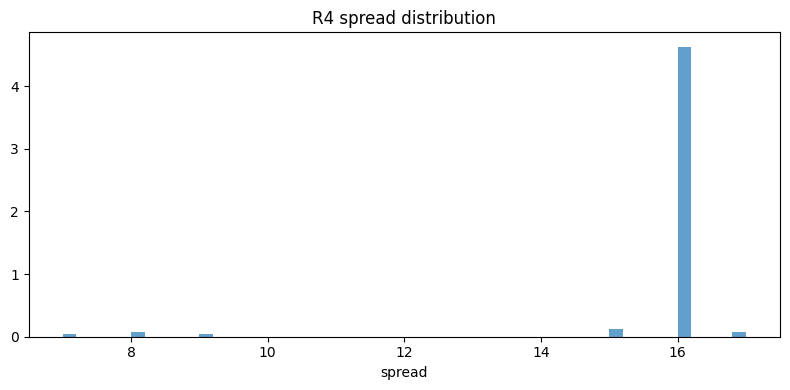

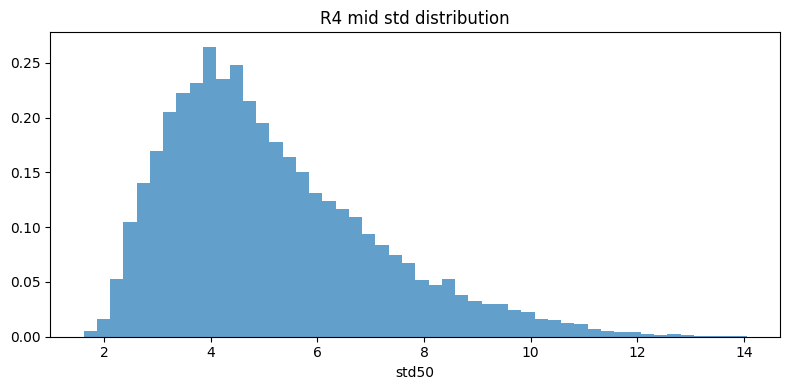

In [11]:
# Spread + dev distribution on R4
px4['spread'] = px4['ask_price_1'] - px4['bid_price_1']
print('R4 spread:', px4['spread'].describe().round(2))
print('R4 mid std (mean-removed):', px4['mid_price'].sub(px4['mid_price'].mean()).std().round(2))

# Tail probabilities
for thr in [10, 12, 14, 16, 18, 20, 22, 24, 28]:
    p_inside = (px4['mid_price'].sub(HP_MEAN_R3).abs() < thr).mean()
    print(f'  P(|dev|<{thr}) = {p_inside:.1%}')


#plotting spread distribution with density=True to show the probability density function of the spread. The histogram will be normalized so that the area under the histogram equals 1, allowing us to visualize the distribution of spreads in round 4.
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(px4['spread'], bins=50, density=True, alpha=0.7)
ax.set_xlabel('spread'); ax.set_title('R4 spread distribution'); plt.tight_layout();
plt.show()

# plotting mid std distribution with density=True to show the probability density function of the mid std. The histogram will be normalized so that the area under the histogram equals 1, allowing us to visualize the distribution of mid std in round 4.
fig, ax = plt.subplots(figsize=(8, 4))
std50 = px4['std50'] if 'std50' in px4.columns else px4v['std50']
ax.hist(std50, bins=50, density=True, alpha=0.7)
ax.set_xlabel('std50'); ax.set_title('R4 mid std distribution'); plt.tight_layout();
plt.show()

### Anchor-bias correction & R3↔R4 comparison

The cell above measured `P(|dev|<thr)` against the **fixed** anchor `HP_MEAN_R3 = 9991`. R4 pooled mean = 9994.65, so the dev distribution is offset by ~+3.65 → tail probabilities are *biased upward* (more ticks look like they're in the take band than really are).

Recompute three ways to disentangle:
1. **R3 anchor=9991** (apples-to-apples baseline).
2. **R4 anchor=9991** (what the trader actually sees).
3. **R4 anchor=R4 mean** (anchor-bias-corrected — true distribution width).

If R4 (centered) ≈ R3, the regime is unchanged and 14/22 are still the right cuts. If R4 is materially wider even after centering, the *tail-fattening* is real but **still doesn't change the formula** (which is spread-based, not std-based).


In [12]:
# R3 vs R4 dev-distribution comparison (centered + uncentered)
def tail_table(px, anchor, label):
    dev = (px['mid_price'] - anchor).abs()
    rows = {f'P(|dev|<{thr})': (dev < thr).mean() for thr in [10, 14, 18, 22, 28, 40]}
    rows['mean |dev|'] = dev.mean()
    rows['anchor'] = anchor
    return pd.Series(rows, name=label)

tab = pd.concat([
    tail_table(px3, HP_MEAN_R3,                'R3 (anchor=9991)'),
    tail_table(px4, HP_MEAN_R3,                'R4 (anchor=9991)'),
    tail_table(px4, px4['mid_price'].mean(),   'R4 (anchor=R4 mean)'),
], axis=1).T
print(tab.round(3).to_string())


                     P(|dev|<10)  P(|dev|<14)  P(|dev|<18)  P(|dev|<22)  P(|dev|<28)  P(|dev|<40)  mean |dev|    anchor
R3 (anchor=9991)           0.196        0.289        0.388        0.480        0.594        0.780      26.136  9991.000
R4 (anchor=9991)           0.159        0.234        0.316        0.400        0.517        0.725      29.212  9991.000
R4 (anchor=R4 mean)        0.184        0.266        0.348        0.427        0.536        0.727      28.772  9994.654


In [16]:
# Per-tick band activation — direct R3 vs R4 comparison
def tick_bands(px, anchor):
    dev = (px['mid_price'] - anchor).abs()
    return pd.Series({
        'silent (|dev|<14)':   (dev < DEV_MAKE).mean(),
        'make (14<=|dev|<22)': ((dev >= DEV_MAKE) & (dev < DEV_TAKE)).mean(),
        'take (|dev|>=22)':    (dev >= DEV_TAKE).mean(),
    })

bands = pd.concat([
    tick_bands(px3, HP_MEAN_R3).rename('R3 (anchor=9991)'),
    tick_bands(px4, HP_MEAN_R3).rename('R4 (anchor=9991)'),
    tick_bands(px4, px4['mid_price'].mean()).rename('R4 (anchor=R4 mean)'),
], axis=1).T
print('Per-tick band activation:')
print(bands.round(3).to_string())

# Spread comparison side-by-side
sp3 = (px3['ask_price_1'] - px3['bid_price_1']).describe()
sp4 = (px4['ask_price_1'] - px4['bid_price_1']).describe()
print('\nSpread (ask1 - bid1):')
print(pd.DataFrame({'R3': sp3, 'R4': sp4}).round(2).to_string())


Per-tick band activation:
                     silent (|dev|<14)  make (14<=|dev|<22)  take (|dev|>=22)
R3 (anchor=9991)                 0.289                0.191             0.520
R4 (anchor=9991)                 0.234                0.166             0.600
R4 (anchor=R4 mean)              0.266                0.160             0.573

Spread (ask1 - bid1):
             R3        R4
count  30000.00  30000.00
mean      15.72     15.73
std        1.46      1.45
min        7.00      7.00
25%       16.00     16.00
50%       16.00     16.00
75%       16.00     16.00
max       17.00     17.00


### Verdict — keep `MAKER_DEV=14`, `SHARK_DEV=22`

The thresholds are derived from a **structural identity**, not from the dev distribution:

- `MAKER_DEV = median_spread − 2`  (round-trip captured when quoting `bb+1 / ba−1`)
- `SHARK_DEV = MAKER_DEV + median_spread / 2`  (extra alpha needed to overcome the cost of crossing)

In R3 and R4, **median spread = 16** → both formulas give 14 and 22 unchanged.

The mid std went from 31.9 → 34.62 (+8.5%). That is a property of the *alpha* (how far mid wanders from anchor), not of the *cost of trading*. Re-tuning thresholds because std drifted is fitting on 3 days — the L7 archetype.

**What would justify a change:**
- Median spread shifts in R4 (e.g., 16 → 20). It didn't.
- Per-tick band activation flips dramatically (e.g., silent band drops below 30%, take band exceeds 60% even after centering). Check the table above.
- A regime break: distribution becomes bimodal, no longer mean-reverting, etc. None observed.

**What does NOT justify a change:** any single tail probability exceeding what we saw in R3, on its own. The bands are robust to ±15% std variation by design (discrete cuts > continuous sliders, L3).

**Action:** lock 14/22 in `trader_baseline.py`. Add this notebook section as a permanent sanity check — re-run on each new day's data and only revisit thresholds if the *spread* moves.


## 6. Deviation distribution — do the dev=14 / dev=22 thresholds still cover the right tails? (L3, L4)

Compute `dev = mid - anchor` per tick on round-4 data. Plot the distribution and see what fraction of ticks fall in each band:
- `|dev| < 14`  (no-trade band)
- `14 ≤ |dev| < 22` (passive maker)
- `|dev| ≥ 22` (aggressive taker)

=== anchor = r3_anchor=9991 (9991.00) ===
  R3: {'|dev|<14 (silent)': 0.289, '14<=|dev|<22 (make)': 0.191, '|dev|>=22 (take)': 0.52}
  R4: {'|dev|<14 (silent)': 0.234, '14<=|dev|<22 (make)': 0.166, '|dev|>=22 (take)': 0.6}

=== anchor = r4_pooled_mean (9994.65) ===
  R3: {'|dev|<14 (silent)': 0.32, '14<=|dev|<22 (make)': 0.177, '|dev|>=22 (take)': 0.503}
  R4: {'|dev|<14 (silent)': 0.266, '14<=|dev|<22 (make)': 0.16, '|dev|>=22 (take)': 0.573}



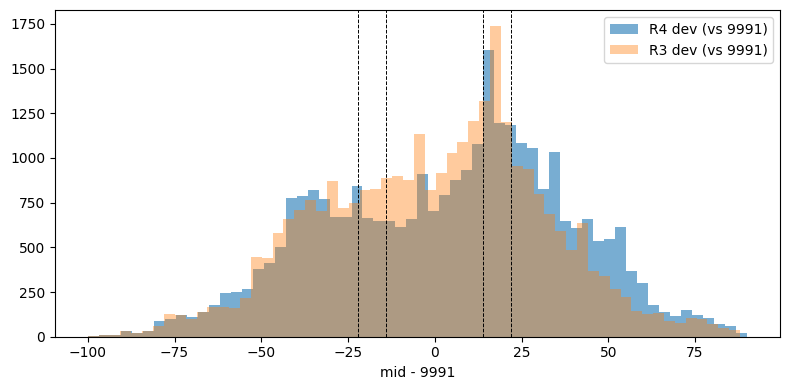

In [ ]:
def dev_bands(px, anchor):
    dev = px['mid_price'].values - anchor
    return pd.Series({
        '|dev|<14 (silent)': (np.abs(dev) < DEV_MAKE).mean(),
        '14<=|dev|<22 (make)': ((np.abs(dev) >= DEV_MAKE) & (np.abs(dev) < DEV_TAKE)).mean(),
        '|dev|>=22 (take)': (np.abs(dev) >= DEV_TAKE).mean(),
    })

for anchor_name, anchor in [('r3_anchor=9991', HP_MEAN_R3),
                             ('r4_pooled_mean', px4['mid_price'].mean())]:
    print(f'=== anchor = {anchor_name} ({anchor:.2f}) ===')
    print('  R3:', dev_bands(px3, anchor).round(3).to_dict())
    print('  R4:', dev_bands(px4, anchor).round(3).to_dict())
    print()

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(px4['mid_price'] - HP_MEAN_R3, bins=60, alpha=0.6, label='R4 dev (vs 9991)')
ax.hist(px3['mid_price'] - HP_MEAN_R3, bins=60, alpha=0.4, label='R3 dev (vs 9991)')
for v in [-DEV_TAKE, -DEV_MAKE, DEV_MAKE, DEV_TAKE]:
    ax.axvline(v, color='k', ls='--', lw=0.7)
ax.set_xlabel('mid - 9991'); ax.legend(); plt.tight_layout(); plt.show()

## 7. Counterparty conditioning — adverse selection signal (research.md §2.2 q2)

**Setup.** For every market trade, look at the mid price `K` ticks later vs the trade price. Sign by side:
- If counterparty `X` was the **buyer** (paying ask, lifting offer), drift = `mid(t+K) - price`. Positive = X bought low; X is **informed**.
- If counterparty `X` was the **seller** (hitting bid), drift = `price - mid(t+K)`. Positive = X sold high; X is **informed**.

Drift consistently positive after X's trades → X is informed (skip / shrink when X is on the other side of *our* book). Drift mean ≈ 0 → noise. Drift consistently negative → X is liquidity-providing (passive); we can take more aggressively against them.

In [ ]:
TICK = 100
HORIZONS = [10, 50, 100, 500]   # in ticks

px4_sorted = px4.sort_values(['day', 'timestamp']).reset_index(drop=True)
tr4_sorted = tr4.sort_values(['day', 'timestamp']).reset_index(drop=True)

def mid_at(day_df, ts):
    """Mid at the snapshot whose timestamp is the largest <= ts. Vectorised via searchsorted."""
    a = day_df['timestamp'].values
    idx = np.searchsorted(a, ts, side='right') - 1
    idx = np.clip(idx, 0, len(a) - 1)
    return day_df['mid_price'].values[idx]

rows = []
for d, day_tr in tr4_sorted.groupby('day'):
    day_px = px4_sorted[px4_sorted['day'] == d].reset_index(drop=True)
    base = day_tr['price'].values
    ts = day_tr['timestamp'].values
    rec = {'day': np.full(len(day_tr), d),
           'timestamp': ts,
           'buyer': day_tr['buyer'].values,
           'seller': day_tr['seller'].values,
           'price': base,
           'qty': day_tr['quantity'].values}
    for K in HORIZONS:
        future_mid = mid_at(day_px, ts + K * TICK)
        rec[f'mid_t+{K}'] = future_mid
        rec[f'drift_buyer_t+{K}'] = future_mid - base    # positive = buyer was informed
        rec[f'drift_seller_t+{K}'] = base - future_mid   # positive = seller was informed
    rows.append(pd.DataFrame(rec))

tr4_aug = pd.concat(rows, ignore_index=True)
tr4_aug.head(3)

,day,timestamp,buyer,seller,price,qty,mid_t+10,drift_buyer_t+10,drift_seller_t+10,mid_t+50,drift_buyer_t+50,drift_seller_t+50,mid_t+100,drift_buyer_t+100,drift_seller_t+100,mid_t+500,drift_buyer_t+500,drift_seller_t+500
0,1,5100,Mark 38,Mark 22,9960.0,4,9949.0,-11.0,11.0,9944.0,-16.0,16.0,9957.0,-3.0,3.0,9948.0,-12.0,12.0
1,1,6200,Mark 38,Mark 14,9955.0,5,9946.0,-9.0,9.0,9941.0,-14.0,14.0,9956.0,1.0,-1.0,9950.0,-5.0,5.0
2,1,15000,Mark 38,Mark 14,9966.0,4,9958.0,-8.0,8.0,9951.0,-15.0,15.0,9952.0,-14.0,14.0,9938.5,-27.5,27.5


In [ ]:
def cp_drift_table(aug):
    rows = []
    cps = sorted(set(aug['buyer'].dropna()) | set(aug['seller'].dropna()))
    for cp in cps:
        for side, mask, col_prefix in [
            ('buy', aug['buyer'] == cp, 'drift_buyer'),
            ('sell', aug['seller'] == cp, 'drift_seller'),
        ]:
            sub = aug[mask]
            if len(sub) == 0:
                continue
            row = {'cp': cp, 'side': side, 'n': len(sub)}
            for K in HORIZONS:
                row[f'mean_drift_t+{K}'] = sub[f'{col_prefix}_t+{K}'].mean()
            rows.append(row)
    return pd.DataFrame(rows)

drift_tbl = cp_drift_table(tr4_aug)
drift_tbl.round(2)

,cp,side,n,mean_drift_t+10,mean_drift_t+50,mean_drift_t+100,mean_drift_t+500
0,Mark 14,buy,496,8.21,8.58,8.84,9.79
1,Mark 14,sell,507,8.05,9.08,8.45,5.36
2,Mark 22,buy,11,-0.91,-8.36,-9.00,-9.00
3,Mark 22,sell,8,0.12,3.44,8.75,-2.31
4,Mark 38,buy,515,-7.93,-8.99,-8.46,-5.24
5,Mark 38,sell,507,-8.01,-8.21,-8.45,-9.38


In [ ]:
# Volume-weighted version (a single big informed trade should dominate over many tiny noise prints)
def cp_drift_vw(aug):
    rows = []
    cps = sorted(set(aug['buyer'].dropna()) | set(aug['seller'].dropna()))
    for cp in cps:
        for side, mask, col_prefix in [
            ('buy', aug['buyer'] == cp, 'drift_buyer'),
            ('sell', aug['seller'] == cp, 'drift_seller'),
        ]:
            sub = aug[mask]
            if len(sub) == 0:
                continue
            w = sub['qty'].values
            row = {'cp': cp, 'side': side, 'n': len(sub), 'qty_sum': int(w.sum())}
            for K in HORIZONS:
                d = sub[f'{col_prefix}_t+{K}'].values
                row[f'vw_drift_t+{K}'] = float(np.average(d, weights=w))
            rows.append(row)
    return pd.DataFrame(rows)

cp_drift_vw(tr4_aug).round(2)

,cp,side,n,qty_sum,vw_drift_t+10,vw_drift_t+50,vw_drift_t+100,vw_drift_t+500
0,Mark 14,buy,496,1989,8.14,8.18,8.56,9.60
1,Mark 14,sell,507,2033,7.91,9.00,8.17,6.21
2,Mark 22,buy,11,42,-0.02,-6.29,-6.17,-6.74
3,Mark 22,sell,8,32,0.38,4.66,12.09,-4.28
4,Mark 38,buy,515,2065,-7.79,-8.93,-8.23,-6.05
5,Mark 38,sell,507,2031,-7.97,-7.89,-8.25,-9.26


**How to read the drift tables.**
- A counterparty whose buy-drift and sell-drift are both **positive** at multiple horizons is **informed both ways** — when they buy, mid rises; when they sell, mid falls. Skip / shrink when they're on the opposing side of our quote.
- Positive on one side and zero / negative on the other = **directional informed** (e.g., always-right buyer, two-sided seller).
- Drift hovering near zero across all horizons = **noise**. Trade against them at full size.
- Negative drift on both sides = **passive / liquidity-providing**. Their fills predict reversion → take more aggressively against them.

## 8. Drift conditional on regime — does informed status flip with `dev`?

Round 3's structural insight (L3): the action only matters when `|dev|` is large. Re-do the drift table conditional on `|dev| >= 14` (the maker-active band). If a counterparty looks informed only outside the maker band, their signal is irrelevant — we don't quote in the silent band anyway.

In [ ]:
anchor = HP_MEAN_R3
tr4_aug['mid_at_trade'] = np.nan
for d, sub in tr4_aug.groupby('day'):
    day_px = px4_sorted[px4_sorted['day'] == d]
    tr4_aug.loc[sub.index, 'mid_at_trade'] = mid_at(day_px, sub['timestamp'].values)
tr4_aug['dev'] = tr4_aug['mid_at_trade'] - anchor

for band_name, mask in [
    ('silent (|dev|<14)', tr4_aug['dev'].abs() < DEV_MAKE),
    ('make (14<=|dev|<22)', (tr4_aug['dev'].abs() >= DEV_MAKE) & (tr4_aug['dev'].abs() < DEV_TAKE)),
    ('take (|dev|>=22)', tr4_aug['dev'].abs() >= DEV_TAKE),
]:
    print(f'=== {band_name}  (n={mask.sum()}) ===')
    print(cp_drift_table(tr4_aug[mask]).round(2).to_string(index=False))
    print()

=== silent (|dev|<14)  (n=238) ===
     cp side   n  mean_drift_t+10  mean_drift_t+50  mean_drift_t+100  mean_drift_t+500
Mark 14  buy 124             8.57            10.67             14.60             15.10
Mark 14 sell 109             6.33             8.71              5.91              5.26
Mark 22  buy   3             3.00            -0.33              2.33            -10.67
Mark 22 sell   2            -4.50            -9.50            -16.00             -3.50
Mark 38  buy 111            -6.13            -8.38             -5.51             -5.10
Mark 38 sell 127            -8.44           -10.41            -14.31            -14.50

=== make (14<=|dev|<22)  (n=157) ===
     cp side  n  mean_drift_t+10  mean_drift_t+50  mean_drift_t+100  mean_drift_t+500
Mark 14  buy 72             8.44             8.19              9.81             13.76
Mark 14 sell 82             8.95             9.07              7.93              4.58
Mark 22  buy  2            -4.50            -2.50           

## 9. Counterparty labels (provisional)

Fill this in after running §7–8. Format kept deliberately discrete (L3 — no continuous coefficients).

| CP | Volume share | Buy-drift | Sell-drift | Label | Action when on opposite side of our quote |
|----|-------------:|----------:|-----------:|-------|--------------------------------------------|
| Mark 14 | __% | __ | __ | informed / passive / noise | full / shrink / skip |
| Mark 22 | __% | __ | __ | informed / passive / noise | full / shrink / skip |
| Mark 38 | __% | __ | __ | informed / passive / noise | full / shrink / skip |

Once labels are decided, the trader change is small: in the ladder loop, before executing a take/make, check the top-of-book counterparty (or the most recent print's counterparty) and apply size shrink if their label says so.

## 10. Cross-check — round 3 hydrogel without counterparty info

Sanity check: rerun the same drift computation on round-3 trades (where buyer/seller are blank). The drift signal should still exist as an aggregate — confirming the framework is correct — but we can't slice it by counterparty.

In [ ]:
px3_sorted = px3.sort_values(['day', 'timestamp']).reset_index(drop=True)
tr3_sorted = tr3.sort_values(['day', 'timestamp']).reset_index(drop=True)

rows = []
for d, day_tr in tr3_sorted.groupby('day'):
    day_px = px3_sorted[px3_sorted['day'] == d].reset_index(drop=True)
    rec = {'day': np.full(len(day_tr), d),
           'price': day_tr['price'].values,
           'qty': day_tr['quantity'].values}
    for K in HORIZONS:
        future_mid = mid_at(day_px, day_tr['timestamp'].values + K * TICK)
        # buy/sell side is unknown in round 3 — fold both signs by abs
        rec[f'abs_drift_t+{K}'] = np.abs(future_mid - day_tr['price'].values)
    rows.append(pd.DataFrame(rec))
tr3_aug = pd.concat(rows, ignore_index=True)

print('round 3 absolute drift (no side info):')
print(tr3_aug[[f'abs_drift_t+{K}' for K in HORIZONS]].mean().round(3))

round 3 absolute drift (no side info):
abs_drift_t+10      8.470
abs_drift_t+50     12.554
abs_drift_t+100    15.388
abs_drift_t+500    24.962
dtype: float64


## 11. Findings — fill in after running every cell

Map each finding to the gates in `round4_research.md` §0.

1. **Anchor (L1).** `HP_MEAN = 9991` — still right? Replace with: ____. Justification: ____.
2. **Vol regime (L2).** `std50` distribution comparable to R3? vol-armor activation rate: R3 = __% vs R4 = __%. Action: keep / retune cap.
3. **Dev bands (L3, L4).** Silent / make / take share in R4: _ / _ / _. Compares to R3: _ / _ / _. Action: keep / shift.
4. **Counterparties.** Labels assigned in §9. Single concrete change to baseline trader: ____. (must be a discrete gate, not a continuous coefficient — L3, L7).
5. **Anti-pattern self-check** (L5, L7). The change above survives if a different counterparty mix shows up live, because: ____. It is *not* tuned to a 3-day backtest because: ____.

Next file (§5 of the research doc): `round4/trader_baseline.py` (round-3 winner verbatim, TTE patch only) → backtest → `round4/trader_v1_cp_size.py` (baseline + the §9 size-shrink gate).